# Understanding Where Work Gets Stuck

**Section 5 of Baseline System Productivity Report**

> These metrics help identify productivity bottlenecks. As a leader, use them in aggregate to monitor patterns across teams.

## What we're measuring

1. **Cycle Time**: Total PR lifetime (first commit → merge)
2. **Cycle Time Breakdown**:
   - Progress time: coding phase (first commit → review requested)
   - Review time: review phase (review requested → approved)
   - Merge time: merge phase (approved → merged)
3. **Batch Size**: Lines changed (additions + deletions)
4. **Time to First Review**: How quickly PRs get initial feedback

## Data source

Swarmia pre-calculates cycle time components in seconds. We'll convert to hours for readability.

In [1]:
import snowflake.connector
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Connect using SSO (will open browser)
conn = snowflake.connector.connect(
    account='wt74883-sb_prod',
    user='jeroen.vaelen@happening.xyz',
    authenticator='externalbrowser'
)

def run_query(sql):
    """Run SQL and return pandas DataFrame"""
    cur = conn.cursor()
    cur.execute(sql)
    df = cur.fetch_pandas_all()
    df.columns = df.columns.str.lower()
    return df

print('Connected!')

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/2c8cda8f-751e-4798-8680-5761f91d4e40/saml2?SAMLRequest=lZJRb9owFIX%2FSuQ9J3ZCgMQCKlZWDQ0oK3TT%2BjIZxwGvjh1spyH%2Ffk4AqX1opb5Fzjn%2Bju%2B5o5tTIbwXpg1XcgzCAAGPSaoyLvdj8Li98xPgGUtkRoSSbAwaZsDNZGRIIUo8rexBPrBjxYz13EXS4PbHGFRaYkUMN1iSghlsKd5MlwscBQgTY5i2DgculsxwxzpYW2II67oO6l6g9B5GCCGIUuhUreQLeIUoP2aUWllFlbhaTu5N7yBCiOIW4RSOsL4Yv3J5HsFHlN1ZZPD37Xbtr%2B83W%2BBNr6%2B7VdJUBdMbpl84ZY8Pi3MA0yawwzhJer7Z%2FXVJs8BIVeeCPDOqirKy7s7AfcGcZVCoPXeTms%2FGoHzmme3%2F4c3P01IdC3GcKtb7TQaLPt00y%2BbfaqdW1bHZ0B9Pu%2BrwjQLv17XXqO11bkzF5rJt07ojFA18FPko3aIURxFGaRD3kifgzVybXBLbOa%2BRuxxBwalWRuVWScEl61JGNKEZSXJ%2F2A%2BZHw%2FTxE8GCfL7w0GYp2EWsxjBtrMInPcGd0H05HPTGMHX3ssCrlwn89laCU4b707pgtj3KwuDsDvhmZ93UswKwsU0yzQzxlUnhKpvNSPW7bnVFQNwcqa%2B3fTJfw%3D%3D&RelayState=ver%3A3-hint%3A491009301606406-ETMsDgAAAZxBtVeeABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEMCt6RcL3rYaDst8qmpBfPYAAACgm9dtM0TL

 pip install snowflake-connector-python[secure-local-storage]


## 1. Data Exploration

First, let's understand the cycle time data we have.

In [2]:
# Check data availability and compare with/without is_excluded filter
df_overview = run_query("""
SELECT 
  COUNT(*) as total_merged_prs,
  COUNT(CASE WHEN is_excluded = FALSE THEN 1 END) as not_excluded,
  COUNT(CASE WHEN is_excluded = TRUE THEN 1 END) as excluded,
  -- Cycle time comparison (in hours)
  ROUND(AVG(cycle_time_seconds) / 3600.0, 1) as avg_cycle_all,
  ROUND(AVG(CASE WHEN is_excluded = FALSE THEN cycle_time_seconds END) / 3600.0, 1) as avg_cycle_not_excluded,
  ROUND(MEDIAN(cycle_time_seconds) / 3600.0, 1) as median_cycle_all,
  ROUND(MEDIAN(CASE WHEN is_excluded = FALSE THEN cycle_time_seconds END) / 3600.0, 1) as median_cycle_not_excluded
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND github_created_at >= DATEADD('day', -365, CURRENT_DATE)
""")

print("=" * 60)
print("DATA COMPARISON: All PRs vs Excluded=FALSE (Last 365 days)")
print("=" * 60)
print(f"Total merged PRs: {df_overview['total_merged_prs'].iloc[0]:,}")
print(f"  - Not excluded: {df_overview['not_excluded'].iloc[0]:,}")
print(f"  - Excluded: {df_overview['excluded'].iloc[0]:,}")
print(f"\nCycle Time (hours):")
print(f"  All PRs     - Avg: {df_overview['avg_cycle_all'].iloc[0]}h, Median: {df_overview['median_cycle_all'].iloc[0]}h")
print(f"  Not excluded - Avg: {df_overview['avg_cycle_not_excluded'].iloc[0]}h, Median: {df_overview['median_cycle_not_excluded'].iloc[0]}h")
print("=" * 60)
print("\nNote: Swarmia UI likely shows AVERAGE for non-excluded PRs")

DATA COMPARISON: All PRs vs Excluded=FALSE (Last 365 days)
Total merged PRs: 117,191
  - Not excluded: 95,312
  - Excluded: 21,879

Cycle Time (hours):
  All PRs     - Avg: 65.3h, Median: 0.5h
  Not excluded - Avg: 69.2h, Median: 0.9h

Note: Swarmia UI likely shows AVERAGE for non-excluded PRs


In [3]:
# Sample of cycle time data
df_sample = run_query("""
SELECT 
  id,
  github_created_at,
  ROUND(cycle_time_seconds / 3600.0, 1) as cycle_time_hours,
  ROUND(progress_time_seconds / 3600.0, 1) as progress_hours,
  ROUND(review_time_seconds / 3600.0, 1) as review_hours,
  ROUND(merge_time_seconds / 3600.0, 1) as merge_hours,
  additions,
  deletions,
  additions + deletions as lines_changed
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND cycle_time_seconds IS NOT NULL
  AND github_created_at >= '2024-01-01'
ORDER BY github_created_at DESC
LIMIT 10
""")

print("Sample of recent merged PRs with cycle time:")
df_sample

Sample of recent merged PRs with cycle time:


,id,github_created_at,cycle_time_hours,progress_hours,review_hours,merge_hours,additions,deletions,lines_changed
0,93573b88-e6c5-4054-874c-ac0b9f1e110e,2026-02-08 22:45:44,0.0,0.0,0.0,0.0,2,0,2
1,ef0f2374-5427-4615-9a8b-4e9788599f8a,2026-02-08 20:32:48,0.0,0.0,0.0,0.0,5,0,5
2,f35a10a2-ce66-4a2b-952a-94a558c858dd,2026-02-08 18:32:36,1.1,0.0,1.1,None,2,2,4
3,540c03f7-d081-42aa-a656-09497a1452af,2026-02-08 17:36:44,0.0,0.0,0.0,0.0,415,416,831
4,1eda33b8-7bc3-4d3f-90e2-bf4fb26e087a,2026-02-08 17:35:57,0.0,0.0,0.0,0.0,91,91,182
5,708044d8-4241-49de-9c58-5477737cbbb9,2026-02-08 17:35:44,0.0,0.0,0.0,0.0,32,32,64
6,0d1c5f49-5934-4cb7-997c-1e981e8b13e7,2026-02-08 17:35:40,0.0,0.0,0.0,0.0,8,8,16
7,63f148dd-b735-4cab-ab76-0382a9ce0110,2026-02-08 17:35:40,0.0,0.0,0.0,0.0,8,8,16
8,8854334f-0e83-4d55-b500-5140e1c7c6d1,2026-02-08 17:35:40,0.0,0.0,0.0,0.0,9,9,18
9,9dfff787-7537-48eb-9d03-5f393c96a7da,2026-02-08 17:35:37,0.0,0.0,0.0,0.0,5,5,10


## 2. Cycle Time Overview

Total cycle time trend over time.

In [4]:
# Monthly cycle time (excluding current incomplete month)
# IMPORTANT: Filter is_excluded = FALSE to match Swarmia UI
# Note: Swarmia UI shows AVERAGE, not median
df_cycle = run_query("""
SELECT
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs_merged,
  -- Show in days for easier comparison with Swarmia UI
  ROUND(AVG(cycle_time_seconds) / 86400.0, 1) as avg_cycle_days,
  ROUND(MEDIAN(cycle_time_seconds) / 86400.0, 1) as median_cycle_days,
  -- Also keep hours for detail
  ROUND(AVG(cycle_time_seconds) / 3600.0, 1) as avg_cycle_hours,
  ROUND(MEDIAN(cycle_time_seconds) / 3600.0, 1) as median_cycle_hours,
  ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY cycle_time_seconds) / 3600.0, 1) as p75_cycle_hours,
  ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY cycle_time_seconds) / 3600.0, 1) as p90_cycle_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND cycle_time_seconds IS NOT NULL
  AND github_created_at IS NOT NULL
  AND github_created_at >= '2023-01-01'
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_cycle['month_dt'] = pd.to_datetime(df_cycle['month'])

print(f"Data from 2023-01 through: {df_cycle['month'].max()}")
print(f"Filter: is_excluded = FALSE (matching Swarmia UI)")
df_cycle.tail(10)

Data from 2023-01 through: 2026-01-01
Filter: is_excluded = FALSE (matching Swarmia UI)


,month,prs_merged,avg_cycle_days,median_cycle_days,avg_cycle_hours,median_cycle_hours,p75_cycle_hours,p90_cycle_hours,month_dt
27,2025-04-01,7456,3.0,0.1,71.9,1.3,37.9,145.0,2025-04-01
28,2025-05-01,7503,2.6,0.0,63.3,1.0,25.1,143.8,2025-05-01
29,2025-06-01,6571,3.0,0.0,72.3,1.2,28.2,166.0,2025-06-01
30,2025-07-01,8131,3.1,0.0,75.4,0.9,27.2,159.4,2025-07-01
31,2025-08-01,6917,2.8,0.0,68.2,0.7,23.5,168.8,2025-08-01
32,2025-09-01,8102,3.5,0.1,82.9,1.3,42.1,195.1,2025-09-01
33,2025-10-01,9222,3.0,0.0,72.3,0.9,26.7,167.0,2025-10-01
34,2025-11-01,8392,3.3,0.0,79.7,1.1,45.1,192.4,2025-11-01
35,2025-12-01,7593,3.1,0.0,74.4,0.9,25.6,208.2,2025-12-01
36,2026-01-01,8197,1.9,0.0,46.8,0.8,23.3,116.9,2026-01-01


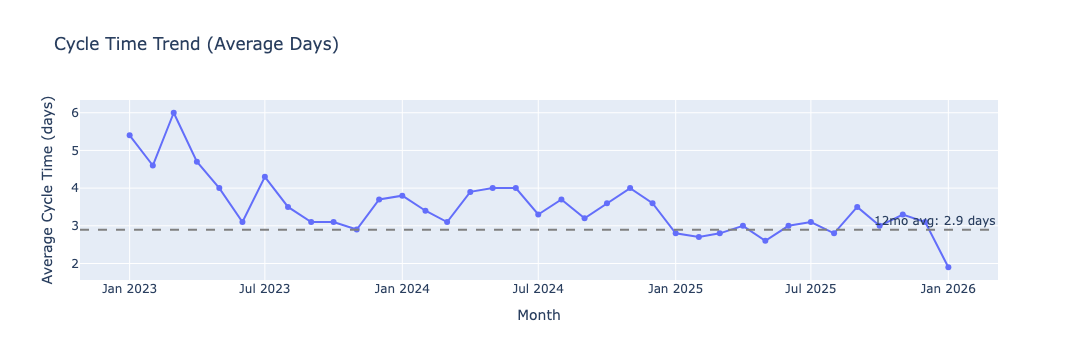


Baseline (last 12 months): 2.9 days average cycle time


In [5]:
# Cycle time trend - showing AVERAGE in DAYS
fig = px.line(df_cycle, x='month', y='avg_cycle_days',
              title='Cycle Time Trend (Average Days)',
              markers=True)
fig.update_layout(yaxis_title='Average Cycle Time (days)', xaxis_title='Month')

# Add 12-month average
recent_12mo = df_cycle[df_cycle['month_dt'] >= df_cycle['month_dt'].max() - pd.DateOffset(months=12)]
avg_12mo = recent_12mo['avg_cycle_days'].mean()
fig.add_hline(y=avg_12mo, line_dash="dash", line_color="gray",
              annotation_text=f"12mo avg: {avg_12mo:.1f} days")

fig.show()

print(f"\nBaseline (last 12 months): {avg_12mo:.1f} days average cycle time")

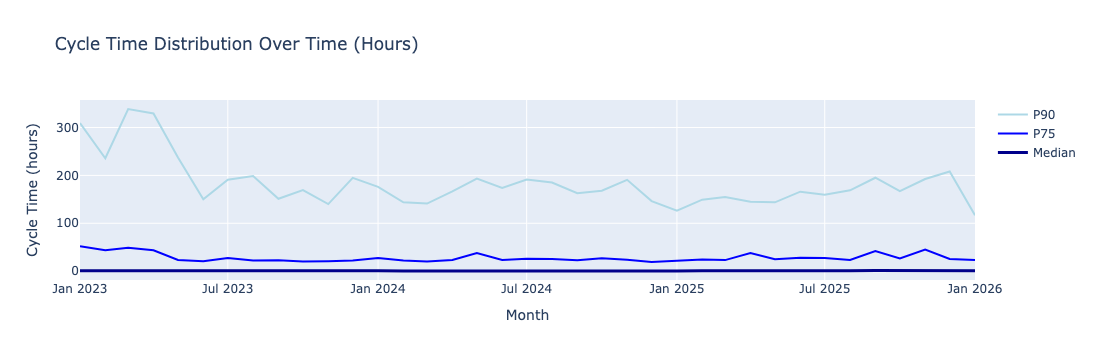

In [6]:
# Cycle time with percentiles (shows distribution spread)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_cycle['month'], y=df_cycle['p90_cycle_hours'],
    name='P90', line=dict(color='lightblue')
))
fig.add_trace(go.Scatter(
    x=df_cycle['month'], y=df_cycle['p75_cycle_hours'],
    name='P75', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=df_cycle['month'], y=df_cycle['median_cycle_hours'],
    name='Median', line=dict(color='darkblue', width=3)
))

fig.update_layout(
    title='Cycle Time Distribution Over Time (Hours)',
    yaxis_title='Cycle Time (hours)',
    xaxis_title='Month'
)
fig.show()

In [7]:
# Distribution of cycle times - where do PRs fall?
# This shows the outlier story: most PRs are fast, but some get stuck
df_distribution = run_query("""
SELECT 
  CASE 
    WHEN cycle_time_seconds <= 3600 THEN '1. < 1 hour'
    WHEN cycle_time_seconds <= 86400 THEN '2. 1h - 1 day'
    WHEN cycle_time_seconds <= 86400 * 3 THEN '3. 1-3 days'
    WHEN cycle_time_seconds <= 86400 * 7 THEN '4. 3-7 days'
    WHEN cycle_time_seconds <= 86400 * 14 THEN '5. 1-2 weeks'
    WHEN cycle_time_seconds <= 86400 * 30 THEN '6. 2-4 weeks'
    ELSE '7. > 1 month'
  END as cycle_time_bucket,
  COUNT(*) as prs,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) as pct
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND cycle_time_seconds IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

# Calculate cumulative percentage
df_distribution['cumulative_pct'] = df_distribution['pct'].cumsum()

print("Cycle Time Distribution (Last 12 months)")
print("=" * 60)
df_distribution

Cycle Time Distribution (Last 12 months)


,cycle_time_bucket,prs,pct,cumulative_pct
0,1. < 1 hour,48449,50.8,50.8
1,2. 1h - 1 day,21987,23.1,73.9
2,3. 1-3 days,8715,9.1,83.0
3,4. 3-7 days,7310,7.7,90.7
4,5. 1-2 weeks,4156,4.4,95.1
5,6. 2-4 weeks,2885,3.0,98.1
6,7. > 1 month,1810,1.9,100.0


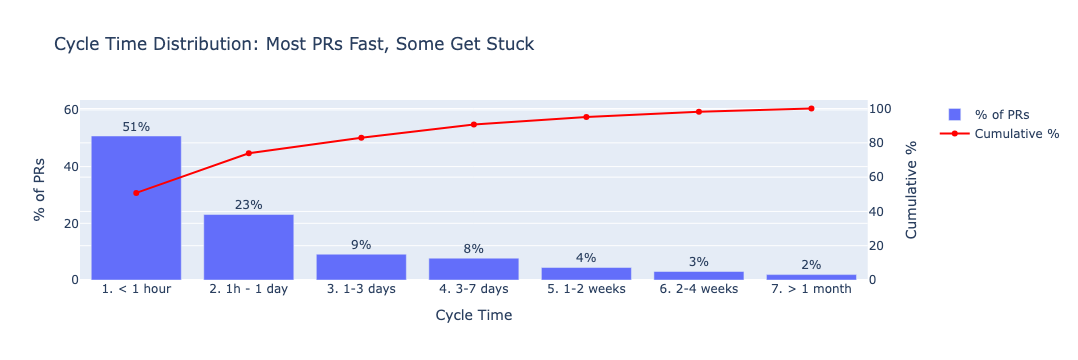


Key insight:
  74% of PRs merge within 1 day (the typical experience)
  5% of PRs take >2 weeks (the outliers pulling up the average)


In [8]:
# Visualize the distribution - bar chart with cumulative line
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Convert to float to avoid Decimal issues
pct_values = df_distribution['pct'].astype(float)
cumulative_values = df_distribution['cumulative_pct'].astype(float)

fig.add_trace(
    go.Bar(x=df_distribution['cycle_time_bucket'], y=pct_values,
           name='% of PRs', text=[f'{x:.0f}%' for x in pct_values],
           textposition='outside'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df_distribution['cycle_time_bucket'], y=cumulative_values,
               name='Cumulative %', mode='lines+markers', line=dict(color='red')),
    secondary_y=True
)

fig.update_layout(
    title='Cycle Time Distribution: Most PRs Fast, Some Get Stuck',
    xaxis_title='Cycle Time'
)
fig.update_yaxes(title_text='% of PRs', secondary_y=False, range=[0, pct_values.max() * 1.25])
fig.update_yaxes(title_text='Cumulative %', secondary_y=True, range=[0, 105])

fig.show()

# Key insight
fast_prs = pct_values[df_distribution['cycle_time_bucket'].isin(['1. < 1 hour', '2. 1h - 1 day'])].sum()
stuck_prs = pct_values[df_distribution['cycle_time_bucket'].isin(['6. 2-4 weeks', '7. > 1 month'])].sum()

print(f"\nKey insight:")
print(f"  {fast_prs:.0f}% of PRs merge within 1 day (the typical experience)")
print(f"  {stuck_prs:.0f}% of PRs take >2 weeks (the outliers pulling up the average)")

## 3. Cycle Time Breakdown

Where does time go? Progress (coding) → Review → Merge

### 3.1 Overall Breakdown (Timeseries)

In [9]:
# Check the distribution of progress time - is it really near zero?
df_progress_dist = run_query("""
SELECT
  CASE 
    WHEN progress_time_seconds < 60 THEN '< 1 min'
    WHEN progress_time_seconds < 3600 THEN '1-60 min'
    WHEN progress_time_seconds < 86400 THEN '1-24 hours'
    ELSE '> 24 hours'
  END as progress_bucket,
  COUNT(*) as prs,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) as pct
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND progress_time_seconds IS NOT NULL
  AND github_created_at >= '2023-01-01'
GROUP BY 1
ORDER BY 1
""")

print("Progress Time Distribution (time from first commit to review requested)")
print("=" * 60)
df_progress_dist

Progress Time Distribution (time from first commit to review requested)


,progress_bucket,prs,pct
0,1-24 hours,21526,7.7
1,1-60 min,78801,28.0
2,< 1 min,151045,53.7
3,> 24 hours,29661,10.6


In [10]:
# Monthly breakdown of cycle time components (average, in hours)
# Filter: is_excluded = FALSE to match Swarmia UI
df_breakdown = run_query("""
SELECT
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs,
  ROUND(AVG(progress_time_seconds) / 3600.0, 1) as avg_progress_hours,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(merge_time_seconds) / 3600.0, 1) as avg_merge_hours,
  -- Also show medians for comparison
  ROUND(MEDIAN(progress_time_seconds) / 3600.0, 1) as median_progress_hours,
  ROUND(MEDIAN(review_time_seconds) / 3600.0, 1) as median_review_hours,
  ROUND(MEDIAN(merge_time_seconds) / 3600.0, 1) as median_merge_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND cycle_time_seconds IS NOT NULL
  AND github_created_at IS NOT NULL
  AND github_created_at >= '2023-01-01'
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_breakdown['month_dt'] = pd.to_datetime(df_breakdown['month'])

print(f"Data from 2023-01 through: {df_breakdown['month'].max()}")
print(f"Filter: is_excluded = FALSE")
df_breakdown.tail(10)

Data from 2023-01 through: 2026-01-01
Filter: is_excluded = FALSE


,month,prs,avg_progress_hours,avg_review_hours,avg_merge_hours,median_progress_hours,median_review_hours,median_merge_hours,month_dt
27,2025-04-01,7456,27.4,48.4,15.1,0.0,0.7,0.1,2025-04-01
28,2025-05-01,7503,28.8,33.0,14.7,0.0,0.5,0.1,2025-05-01
29,2025-06-01,6571,29.9,45.4,13.2,0.0,0.6,0.1,2025-06-01
30,2025-07-01,8131,36.1,41.7,13.6,0.0,0.5,0.1,2025-07-01
31,2025-08-01,6917,33.1,38.6,12.1,0.0,0.6,0.1,2025-08-01
32,2025-09-01,8102,35.2,41.2,22.7,0.0,0.7,0.1,2025-09-01
33,2025-10-01,9222,29.2,44.4,15.6,0.0,0.7,0.1,2025-10-01
34,2025-11-01,8392,38.2,43.1,16.1,0.0,0.7,0.1,2025-11-01
35,2025-12-01,7593,25.1,49.3,18.1,0.0,0.6,0.1,2025-12-01
36,2026-01-01,8197,24.1,22.6,8.2,0.0,0.7,0.1,2026-01-01


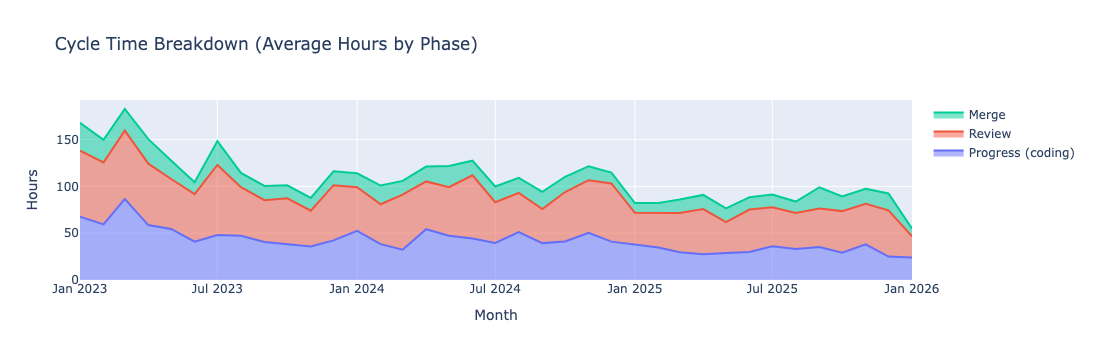

In [11]:
# Stacked area chart showing where time goes (AVERAGE hours)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_breakdown['month'], y=df_breakdown['avg_progress_hours'],
    name='Progress (coding)', stackgroup='one', mode='lines'
))
fig.add_trace(go.Scatter(
    x=df_breakdown['month'], y=df_breakdown['avg_review_hours'],
    name='Review', stackgroup='one', mode='lines'
))
fig.add_trace(go.Scatter(
    x=df_breakdown['month'], y=df_breakdown['avg_merge_hours'],
    name='Merge', stackgroup='one', mode='lines'
))

fig.update_layout(
    title='Cycle Time Breakdown (Average Hours by Phase)',
    yaxis_title='Hours',
    xaxis_title='Month'
)
fig.show()

Cycle Time Breakdown (12-month baseline, AVERAGE hours)
Progress (coding): 31.5h (37%)
Review:            40.0h (47%)
Merge:             14.2h (17%)
Total:             85.7h (3.6 days)


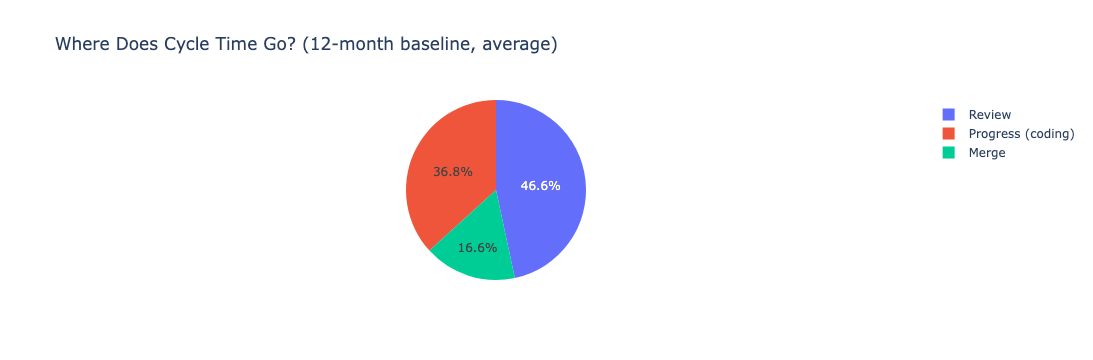

In [12]:
# 12-month average breakdown (current baseline)
recent_12mo = df_breakdown[df_breakdown['month_dt'] >= df_breakdown['month_dt'].max() - pd.DateOffset(months=12)]

avg_progress = recent_12mo['avg_progress_hours'].mean()
avg_review = recent_12mo['avg_review_hours'].mean()
avg_merge = recent_12mo['avg_merge_hours'].mean()
total = avg_progress + avg_review + avg_merge

print("Cycle Time Breakdown (12-month baseline, AVERAGE hours)")
print("=" * 50)
print(f"Progress (coding): {avg_progress:.1f}h ({avg_progress/total*100:.0f}%)")
print(f"Review:            {avg_review:.1f}h ({avg_review/total*100:.0f}%)")
print(f"Merge:             {avg_merge:.1f}h ({avg_merge/total*100:.0f}%)")
print(f"Total:             {total:.1f}h ({total/24:.1f} days)")
print("=" * 50)

# Pie chart
fig = px.pie(
    names=['Progress (coding)', 'Review', 'Merge'],
    values=[avg_progress, avg_review, avg_merge],
    title='Where Does Cycle Time Go? (12-month baseline, average)'
)
fig.show()

### 3.2 Breakdown by PR Speed Category

PRs that take >2 weeks represent a small percentage but pull up the average significantly. Let's compare where time goes for fast vs slow PRs.

In [13]:
# Compare fast PRs vs outliers: where does time go?
df_outlier_breakdown = run_query("""
SELECT 
  CASE 
    WHEN cycle_time_seconds <= 86400 THEN '1. Fast (≤1 day)'
    WHEN cycle_time_seconds <= 86400 * 7 THEN '2. Normal (1-7 days)'
    WHEN cycle_time_seconds <= 86400 * 14 THEN '3. Slow (1-2 weeks)'
    ELSE '4. Outlier (>2 weeks)'
  END as pr_category,
  COUNT(*) as prs,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) as pct_of_total,
  -- Where does time go?
  ROUND(AVG(progress_time_seconds) / 3600.0, 1) as avg_progress_hours,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(merge_time_seconds) / 3600.0, 1) as avg_merge_hours,
  -- PR characteristics
  ROUND(AVG(additions + deletions), 0) as avg_lines,
  ROUND(MEDIAN(additions + deletions), 0) as median_lines
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND cycle_time_seconds IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

print("Comparison: Fast PRs vs Outliers (Last 12 months)")
print("=" * 70)
df_outlier_breakdown

Comparison: Fast PRs vs Outliers (Last 12 months)


,pr_category,prs,pct_of_total,avg_progress_hours,avg_review_hours,avg_merge_hours,avg_lines,median_lines
0,1. Fast (≤1 day),70436,73.9,0.6,2.5,1.1,735,11
1,2. Normal (1-7 days),16025,16.8,22.4,44.6,22.3,1588,68
2,3. Slow (1-2 weeks),4156,4.4,95.0,122.5,59.5,1848,94
3,4. Outlier (>2 weeks),4695,4.9,450.2,387.7,141.9,5268,169


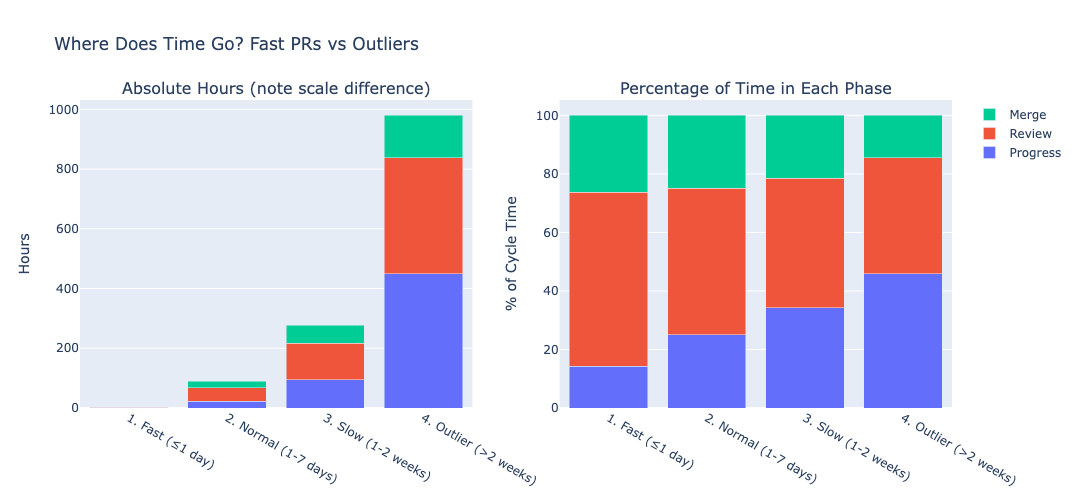


Actual hours by category:
  1. Fast (≤1 day): 0.6h progress + 2.5h review + 1.1h merge = 4.2h total
  2. Normal (1-7 days): 22.4h progress + 44.6h review + 22.3h merge = 89.3h total
  3. Slow (1-2 weeks): 95.0h progress + 122.5h review + 59.5h merge = 277.0h total
  4. Outlier (>2 weeks): 450.2h progress + 387.7h review + 141.9h merge = 979.8h total


In [14]:
# Visualize: Where does time go for each category?
# Use subplots because scale is very different between fast and outlier PRs

categories = df_outlier_breakdown['pr_category'].tolist()
progress = df_outlier_breakdown['avg_progress_hours'].astype(float).tolist()
review = df_outlier_breakdown['avg_review_hours'].astype(float).tolist()
merge = df_outlier_breakdown['avg_merge_hours'].astype(float).tolist()

# Calculate totals and percentages for each category
totals = [p + r + m for p, r, m in zip(progress, review, merge)]
progress_pct = [p/t*100 if t > 0 else 0 for p, t in zip(progress, totals)]
review_pct = [r/t*100 if t > 0 else 0 for r, t in zip(review, totals)]
merge_pct = [m/t*100 if t > 0 else 0 for m, t in zip(merge, totals)]

# Create two charts: absolute hours and percentage breakdown
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Absolute Hours (note scale difference)', 
                                   'Percentage of Time in Each Phase'))

# Left: Absolute hours (stacked)
fig.add_trace(go.Bar(name='Progress', x=categories, y=progress, marker_color='#636EFA'), row=1, col=1)
fig.add_trace(go.Bar(name='Review', x=categories, y=review, marker_color='#EF553B'), row=1, col=1)
fig.add_trace(go.Bar(name='Merge', x=categories, y=merge, marker_color='#00CC96'), row=1, col=1)

# Right: Percentage breakdown (stacked to 100%)
fig.add_trace(go.Bar(name='Progress', x=categories, y=progress_pct, marker_color='#636EFA', showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(name='Review', x=categories, y=review_pct, marker_color='#EF553B', showlegend=False), row=1, col=2)
fig.add_trace(go.Bar(name='Merge', x=categories, y=merge_pct, marker_color='#00CC96', showlegend=False), row=1, col=2)

fig.update_layout(
    barmode='stack',
    title='Where Does Time Go? Fast PRs vs Outliers',
    height=500,
    width=1000
)
fig.update_yaxes(title_text='Hours', row=1, col=1)
fig.update_yaxes(title_text='% of Cycle Time', row=1, col=2)

fig.show()

# Print the actual numbers for clarity
print("\nActual hours by category:")
for i, cat in enumerate(categories):
    print(f"  {cat}: {progress[i]:.1f}h progress + {review[i]:.1f}h review + {merge[i]:.1f}h merge = {totals[i]:.1f}h total")

In [15]:
# Which areas have more outliers?
AREAS = ['Core Experience', 'Data', 'Gaming', 'Platform', 'Player', 'Social', 'Sports']
areas_str = "', '".join(AREAS)

df_outliers_by_area = run_query(f"""
WITH pr_categorized AS (
  SELECT
    f.value::string as area,
    CASE WHEN pr.cycle_time_seconds > 86400 * 14 THEN 1 ELSE 0 END as is_outlier
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.cycle_time_seconds IS NOT NULL
    AND f.value::string IN ('{areas_str}')
    AND pr.github_created_at >= DATEADD('month', -12, CURRENT_DATE)
)
SELECT
  area,
  COUNT(*) as total_prs,
  SUM(is_outlier) as outlier_prs,
  ROUND(100.0 * SUM(is_outlier) / COUNT(*), 1) as outlier_pct
FROM pr_categorized
GROUP BY 1
ORDER BY outlier_pct DESC
""")

print("Outlier Rate by Area (PRs taking >2 weeks)")
print("=" * 50)
df_outliers_by_area

Outlier Rate by Area (PRs taking >2 weeks)


,area,total_prs,outlier_prs,outlier_pct
0,Player,12553,1179,9.4
1,Social,2717,179,6.6
2,Sports,17139,1055,6.2
3,Gaming,5995,352,5.9
4,Core Experience,3791,127,3.4
5,Data,10669,254,2.4
6,Platform,7457,168,2.3


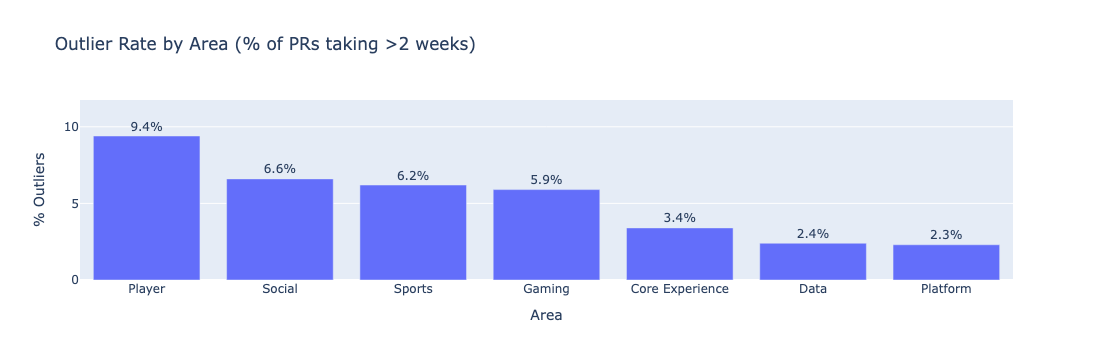


Org-wide outlier rate: 5.5%


In [16]:
# Visualize outlier rate by area
outlier_pct_values = df_outliers_by_area['outlier_pct'].astype(float)

fig = px.bar(df_outliers_by_area, x='area', y='outlier_pct',
             title='Outlier Rate by Area (% of PRs taking >2 weeks)',
             text='outlier_pct')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(
    yaxis_title='% Outliers', 
    xaxis_title='Area',
    yaxis_range=[0, outlier_pct_values.max() * 1.25]
)
fig.show()

# Add org-wide average line for context
org_avg = df_outliers_by_area['outlier_prs'].sum() / df_outliers_by_area['total_prs'].sum() * 100
print(f"\nOrg-wide outlier rate: {org_avg:.1f}%")

In [17]:
# Summary: What do we know about outliers?
print("=" * 60)
print("OUTLIER ANALYSIS SUMMARY")
print("=" * 60)

outlier_data = df_outlier_breakdown[df_outlier_breakdown['pr_category'] == '4. Outlier (>2 weeks)'].iloc[0]
fast_data = df_outlier_breakdown[df_outlier_breakdown['pr_category'] == '1. Fast (≤1 day)'].iloc[0]

print(f"\n1. VOLUME: {float(outlier_data['pct_of_total']):.1f}% of PRs are outliers (>2 weeks)")

print(f"\n2. WHERE TIME GOES (outliers vs fast PRs):")
print(f"   - Progress: {float(outlier_data['avg_progress_hours']):.0f}h vs {float(fast_data['avg_progress_hours']):.1f}h")
print(f"   - Review:   {float(outlier_data['avg_review_hours']):.0f}h vs {float(fast_data['avg_review_hours']):.1f}h")
print(f"   - Merge:    {float(outlier_data['avg_merge_hours']):.0f}h vs {float(fast_data['avg_merge_hours']):.1f}h")

# Which phase has the biggest multiplier?
progress_mult = float(outlier_data['avg_progress_hours']) / max(float(fast_data['avg_progress_hours']), 0.1)
review_mult = float(outlier_data['avg_review_hours']) / max(float(fast_data['avg_review_hours']), 0.1)
merge_mult = float(outlier_data['avg_merge_hours']) / max(float(fast_data['avg_merge_hours']), 0.1)

biggest_diff = max([('Progress', progress_mult), ('Review', review_mult), ('Merge', merge_mult)], key=lambda x: x[1])
print(f"   → Biggest difference: {biggest_diff[0]} ({biggest_diff[1]:.0f}x longer for outliers)")

print(f"\n3. PR SIZE:")
print(f"   - Outliers avg: {int(outlier_data['avg_lines'])} lines")
print(f"   - Fast PRs avg: {int(fast_data['avg_lines'])} lines")
print(f"   → Outliers are {int(outlier_data['avg_lines']) / int(fast_data['avg_lines']):.1f}x larger")

print(f"\n4. BY AREA:")
highest_outlier_area = df_outliers_by_area.iloc[0]
lowest_outlier_area = df_outliers_by_area.iloc[-1]
print(f"   - Highest outlier rate: {highest_outlier_area['area']} ({float(highest_outlier_area['outlier_pct']):.1f}%)")
print(f"   - Lowest outlier rate: {lowest_outlier_area['area']} ({float(lowest_outlier_area['outlier_pct']):.1f}%)")

print("=" * 60)

OUTLIER ANALYSIS SUMMARY

1. VOLUME: 4.9% of PRs are outliers (>2 weeks)

2. WHERE TIME GOES (outliers vs fast PRs):
   - Progress: 450h vs 0.6h
   - Review:   388h vs 2.5h
   - Merge:    142h vs 1.1h
   → Biggest difference: Progress (750x longer for outliers)

3. PR SIZE:
   - Outliers avg: 5268 lines
   - Fast PRs avg: 735 lines
   → Outliers are 7.2x larger

4. BY AREA:
   - Highest outlier rate: Player (9.4%)
   - Lowest outlier rate: Platform (2.3%)


## 4. Batch Size (PR Size)

> Smaller changes get reviewed faster and more thoroughly. Large PRs slow down everything.

In [18]:
# Monthly PR size distribution
# Filter: is_excluded = FALSE to match Swarmia UI
df_size = run_query("""
SELECT
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs,
  ROUND(MEDIAN(additions + deletions), 0) as median_lines,
  ROUND(AVG(additions + deletions), 0) as avg_lines,
  ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY additions + deletions), 0) as p75_lines,
  ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY additions + deletions), 0) as p90_lines,
  COUNT(CASE WHEN additions + deletions > 400 THEN 1 END) as large_prs,
  COUNT(CASE WHEN additions + deletions <= 100 THEN 1 END) as small_prs
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND additions IS NOT NULL
  AND github_created_at IS NOT NULL
  AND github_created_at >= '2023-01-01'
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_size['month_dt'] = pd.to_datetime(df_size['month'])
df_size['pct_large'] = (df_size['large_prs'] / df_size['prs'] * 100).round(1)
df_size['pct_small'] = (df_size['small_prs'] / df_size['prs'] * 100).round(1)

print(f"Data from 2023-01 through: {df_size['month'].max()}")
print(f"Filter: is_excluded = FALSE")
df_size.tail(10)

Data from 2023-01 through: 2026-01-01
Filter: is_excluded = FALSE


,month,prs,median_lines,avg_lines,p75_lines,p90_lines,large_prs,small_prs,month_dt,pct_large,pct_small
27,2025-04-01,7456,13,799,86,460,815,5708,2025-04-01,10.9,76.6
28,2025-05-01,7503,14,817,90,421,774,5719,2025-05-01,10.3,76.2
29,2025-06-01,6571,15,1244,107,527,800,4896,2025-06-01,12.2,74.5
30,2025-07-01,8131,16,1048,98,475,929,6107,2025-07-01,11.4,75.1
31,2025-08-01,6917,14,724,79,372,656,5368,2025-08-01,9.5,77.6
32,2025-09-01,8102,15,1862,96,444,874,6121,2025-09-01,10.8,75.5
33,2025-10-01,9222,18,1396,116,567,1192,6744,2025-10-01,12.9,73.1
34,2025-11-01,8392,16,1291,109,516,1040,6207,2025-11-01,12.4,74.0
35,2025-12-01,7593,20,1200,132,575,1037,5417,2025-12-01,13.7,71.3
36,2026-01-01,8197,20,1400,143,618,1122,5794,2026-01-01,13.7,70.7


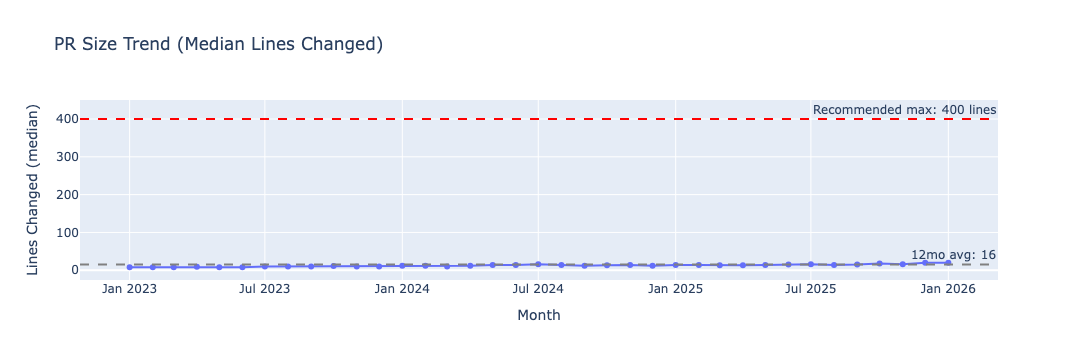


Baseline (last 12 months): 16 lines median PR size


In [19]:
# PR size trend
fig = px.line(df_size, x='month', y='median_lines',
              title='PR Size Trend (Median Lines Changed)',
              markers=True)
fig.update_layout(yaxis_title='Lines Changed (median)', xaxis_title='Month')

# Add benchmark line (400 lines is recommended max)
fig.add_hline(y=400, line_dash="dash", line_color="red",
              annotation_text="Recommended max: 400 lines")

# Add 12-month average
recent_12mo = df_size[df_size['month_dt'] >= df_size['month_dt'].max() - pd.DateOffset(months=12)]
avg_12mo = recent_12mo['median_lines'].mean()
fig.add_hline(y=avg_12mo, line_dash="dash", line_color="gray",
              annotation_text=f"12mo avg: {avg_12mo:.0f}")

fig.show()

print(f"\nBaseline (last 12 months): {avg_12mo:.0f} lines median PR size")

In [41]:
# PR Size distribution - t-shirt sizes
df_size_dist = run_query("""
SELECT 
  CASE 
    WHEN additions + deletions <= 50 THEN '1. XS (≤50)'
    WHEN additions + deletions <= 100 THEN '2. S (51-100)'
    WHEN additions + deletions <= 200 THEN '3. M (101-200)'
    WHEN additions + deletions <= 400 THEN '4. L (201-400)'
    ELSE '5. XL (>400)'
  END as size_bucket,
  COUNT(*) as prs,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) as pct
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND additions IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_size_dist['cumulative_pct'] = df_size_dist['pct'].cumsum()

print("PR Size Distribution (Last 12 months)")
print("=" * 60)
df_size_dist

PR Size Distribution (Last 12 months)


,size_bucket,prs,pct,cumulative_pct
0,1. XS (≤50),63099,66.2,66.2
1,2. S (51-100),8022,8.4,74.6
2,3. M (101-200),7006,7.4,82.0
3,4. L (201-400),5873,6.2,88.2
4,5. XL (>400),11312,11.9,100.1


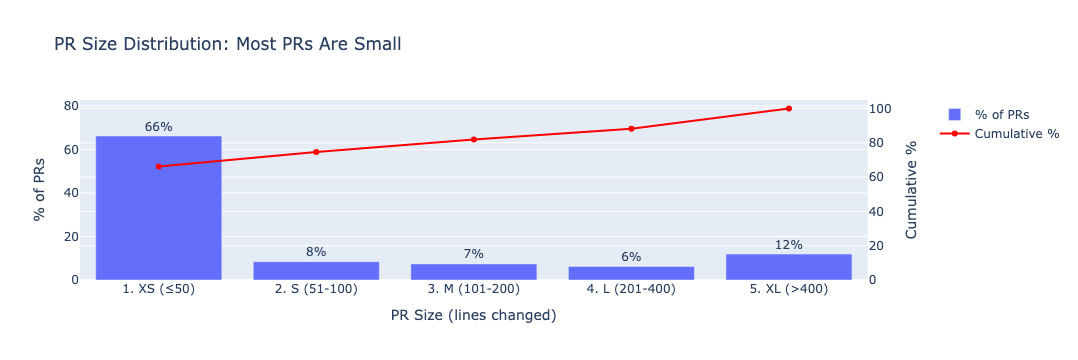


This explains the 16-line median:
  66% of PRs are XS (≤50 lines)
  75% are ≤100 lines


In [42]:
# Visualize PR size distribution
pct_values = df_size_dist['pct'].astype(float)
cumulative_values = df_size_dist['cumulative_pct'].astype(float)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=df_size_dist['size_bucket'], y=pct_values,
           name='% of PRs', text=[f'{x:.0f}%' for x in pct_values],
           textposition='outside'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df_size_dist['size_bucket'], y=cumulative_values,
               name='Cumulative %', mode='lines+markers', line=dict(color='red')),
    secondary_y=True
)

fig.update_layout(
    title='PR Size Distribution: Most PRs Are Small',
    xaxis_title='PR Size (lines changed)'
)
fig.update_yaxes(title_text='% of PRs', secondary_y=False, range=[0, pct_values.max() * 1.25])
fig.update_yaxes(title_text='Cumulative %', secondary_y=True, range=[0, 105])

fig.show()

# Key insight
xs_pct = float(df_size_dist[df_size_dist['size_bucket'] == '1. XS (≤50)']['pct'].iloc[0])
small_pct = cumulative_values[df_size_dist['size_bucket'] == '2. S (51-100)'].values[0]
print(f"\nThis explains the 16-line median:")
print(f"  {xs_pct:.0f}% of PRs are XS (≤50 lines)")
print(f"  {small_pct:.0f}% are ≤100 lines")

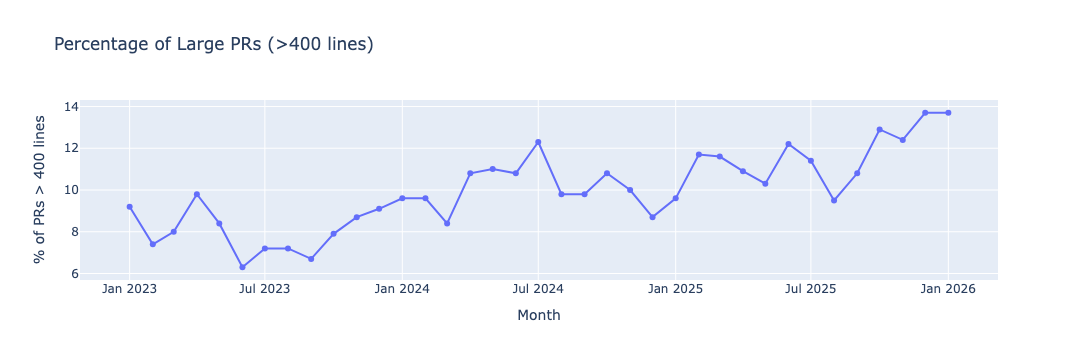


Baseline: 11.6% of PRs are >400 lines (last 12 months)


In [22]:
# Percentage of large PRs over time
fig = px.line(df_size, x='month', y='pct_large',
              title='Percentage of Large PRs (>400 lines)',
              markers=True)
fig.update_layout(yaxis_title='% of PRs > 400 lines', xaxis_title='Month')
fig.show()

# Current baseline
recent_12mo = df_size[df_size['month_dt'] >= df_size['month_dt'].max() - pd.DateOffset(months=12)]
avg_pct_large = recent_12mo['pct_large'].mean()
print(f"\nBaseline: {avg_pct_large:.1f}% of PRs are >400 lines (last 12 months)")

In [ ]:
# Correlation: PR size vs cycle time
# Filter: is_excluded = FALSE
df_size_vs_cycle = run_query("""
SELECT 
  CASE 
    WHEN additions + deletions <= 50 THEN '1. XS (≤50)'
    WHEN additions + deletions <= 100 THEN '2. S (51-100)'
    WHEN additions + deletions <= 200 THEN '3. M (101-200)'
    WHEN additions + deletions <= 400 THEN '4. L (201-400)'
    ELSE '5. XL (>400)'
  END as size_bucket,
  COUNT(*) as prs,
  ROUND(AVG(cycle_time_seconds) / 86400.0, 1) as avg_cycle_days,
  ROUND(MEDIAN(cycle_time_seconds) / 86400.0, 1) as median_cycle_days
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND cycle_time_seconds IS NOT NULL
  AND additions IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

max_y = df_size_vs_cycle['avg_cycle_days'].astype(float).max() * 1.3

fig = go.Figure()

# Benchmark zones: Great < 1 day, Good < 5 days, Needs Attention >= 5 days
fig.add_shape(type="rect", x0=-0.5, x1=4.5, y0=0, y1=1, xref="x", yref="y",
              fillcolor="green", opacity=0.2, layer="below", line_width=0)
fig.add_shape(type="rect", x0=-0.5, x1=4.5, y0=1, y1=5, xref="x", yref="y",
              fillcolor="orange", opacity=0.2, layer="below", line_width=0)
if max_y > 5:
    fig.add_shape(type="rect", x0=-0.5, x1=4.5, y0=5, y1=max_y, xref="x", yref="y",
                  fillcolor="red", opacity=0.15, layer="below", line_width=0)

fig.add_hline(y=1, line_dash="dot", line_color="darkgreen", line_width=1)
fig.add_hline(y=5, line_dash="dot", line_color="darkorange", line_width=1)

fig.add_trace(go.Bar(
    x=df_size_vs_cycle['size_bucket'], 
    y=df_size_vs_cycle['avg_cycle_days'].astype(float),
    marker_color='steelblue',
    text=[f"{d:.1f}d\n(n={n:,})" for d, n in zip(df_size_vs_cycle['avg_cycle_days'].astype(float), df_size_vs_cycle['prs'].astype(int))],
    textposition='outside'
))

# Add legend for benchmark tiers
for tier, color, label in [('Great', 'green', 'Great (<1d)'), ('Good', 'orange', 'Good (<5d)'),
                            ('Needs Attention', 'red', 'Needs Attention (≥5d)')]:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(size=12, color=color, symbol='square'),
        name=label, legendgroup='tiers', legendgrouptitle_text='Cycle Time Tiers'))

fig.update_layout(
    title='PR Size vs Cycle Time (Last 12 months, Average)',
    xaxis_title='PR Size', yaxis_title='Average Cycle Time (days)',
    yaxis=dict(range=[0, max_y]),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)
fig.show()

print("\nKey insight: Larger PRs take longer to merge")
df_size_vs_cycle

## 5. Time to First Review

> The gap between opening a PR and getting a first look. This is where most delays happen.

In [24]:
# Time to first review (calculated from timestamps)
# Filter: is_excluded = FALSE to match Swarmia UI
df_first_review = run_query("""
SELECT
  DATE_TRUNC('month', github_created_at)::DATE as month,
  COUNT(*) as prs_with_review,
  -- Show average to match Swarmia UI
  ROUND(AVG(DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as avg_hours_to_first_review,
  ROUND(MEDIAN(DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as median_hours_to_first_review,
  ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as p75_hours,
  ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as p90_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND first_review_request_at IS NOT NULL
  AND first_reviewed_at IS NOT NULL
  AND first_reviewed_at > first_review_request_at
  AND github_created_at IS NOT NULL
  AND github_created_at >= '2023-01-01'
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_first_review['month_dt'] = pd.to_datetime(df_first_review['month'])

print(f"Data from 2023-01 through: {df_first_review['month'].max()}")
print(f"Filter: is_excluded = FALSE")
df_first_review.tail(10)

Data from 2023-01 through: 2026-01-01
Filter: is_excluded = FALSE


,month,prs_with_review,avg_hours_to_first_review,median_hours_to_first_review,p75_hours,p90_hours,month_dt
27,2025-04-01,3462,24.8,0.3,4.4,42.9,2025-04-01
28,2025-05-01,3564,15.0,0.3,2.7,25.9,2025-05-01
29,2025-06-01,3222,18.5,0.3,4.0,40.9,2025-06-01
30,2025-07-01,3819,18.4,0.3,4.2,26.7,2025-07-01
31,2025-08-01,3045,23.8,0.4,4.1,64.8,2025-08-01
32,2025-09-01,3841,18.0,0.3,5.3,27.7,2025-09-01
33,2025-10-01,4377,20.1,0.3,5.2,45.5,2025-10-01
34,2025-11-01,3790,19.4,0.4,5.9,46.5,2025-11-01
35,2025-12-01,3613,24.0,0.4,4.7,29.5,2025-12-01
36,2026-01-01,4090,13.0,0.4,4.1,37.4,2026-01-01


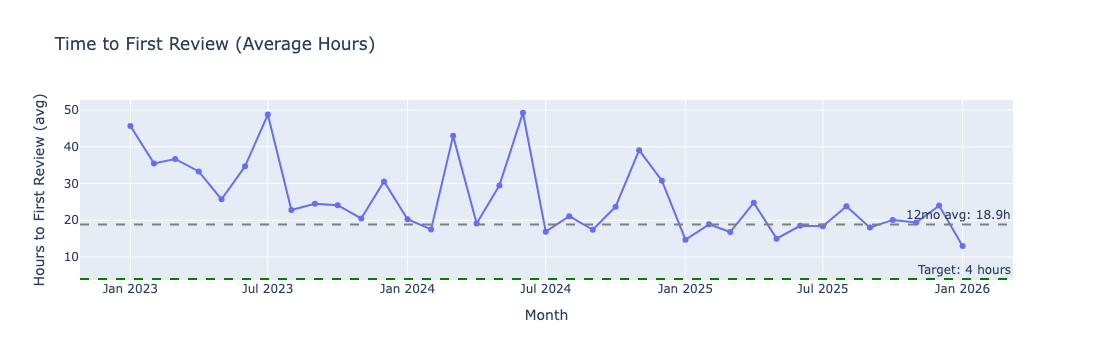


Baseline (last 12 months): 18.9 hours average time to first review


In [25]:
# Time to first review trend - using AVERAGE to match Swarmia UI
fig = px.line(df_first_review, x='month', y='avg_hours_to_first_review',
              title='Time to First Review (Average Hours)',
              markers=True)
fig.update_layout(yaxis_title='Hours to First Review (avg)', xaxis_title='Month')

# Add benchmark (4 hours is common target)
fig.add_hline(y=4, line_dash="dash", line_color="green",
              annotation_text="Target: 4 hours")

# Add 12-month average
recent_12mo = df_first_review[df_first_review['month_dt'] >= df_first_review['month_dt'].max() - pd.DateOffset(months=12)]
avg_12mo = recent_12mo['avg_hours_to_first_review'].mean()
fig.add_hline(y=avg_12mo, line_dash="dash", line_color="gray",
              annotation_text=f"12mo avg: {avg_12mo:.1f}h")

fig.show()

print(f"\nBaseline (last 12 months): {avg_12mo:.1f} hours average time to first review")

### 5.1 Review Time - Deep Dive

Review time (from review requested → approved) averages 40h and makes up 47% of cycle time. Let's break this down.

In [26]:
# Distribution of REVIEW TIME (full phase: review requested → approved)
df_review_time_dist = run_query("""
SELECT 
  CASE 
    WHEN review_time_seconds <= 3600 THEN '1. < 1 hour'
    WHEN review_time_seconds <= 14400 THEN '2. 1-4 hours'
    WHEN review_time_seconds <= 28800 THEN '3. 4-8 hours'
    WHEN review_time_seconds <= 86400 THEN '4. 8-24 hours'
    WHEN review_time_seconds <= 172800 THEN '5. 1-2 days'
    WHEN review_time_seconds <= 604800 THEN '6. 2-7 days'
    ELSE '7. > 1 week'
  END as time_bucket,
  COUNT(*) as prs,
  ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) as pct
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND review_time_seconds IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_review_time_dist['cumulative_pct'] = df_review_time_dist['pct'].cumsum()

print("Review Time Distribution (Last 12 months)")
print("Review time = from review requested until approved")
print("=" * 60)
df_review_time_dist

Review Time Distribution (Last 12 months)
Review time = from review requested until approved


,time_bucket,prs,pct,cumulative_pct
0,1. < 1 hour,33440,54.9,54.9
1,2. 1-4 hours,6885,11.3,66.2
2,3. 4-8 hours,1885,3.1,69.3
3,4. 8-24 hours,6746,11.1,80.4
4,5. 1-2 days,2915,4.8,85.2
5,6. 2-7 days,5922,9.7,94.9
6,7. > 1 week,3139,5.2,100.1


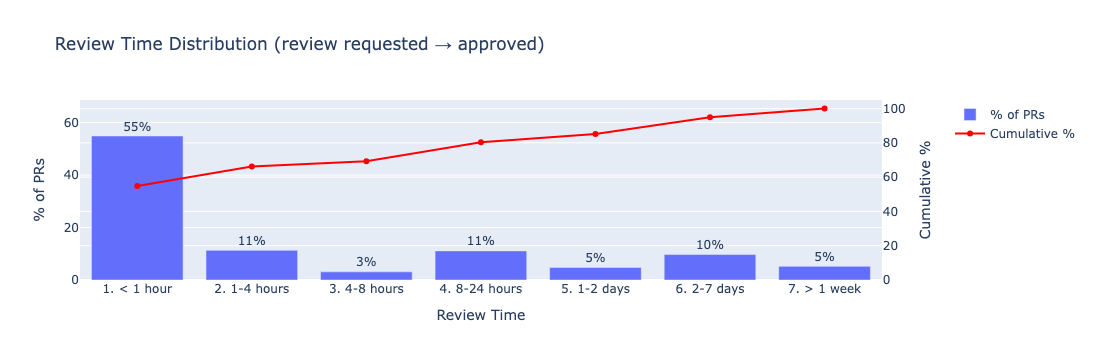


Key insight:
  66% of PRs complete review within 4 hours
  15% take more than 2 days in review


In [27]:
# Visualize review time distribution
pct_values = df_review_time_dist['pct'].astype(float)
cumulative_values = df_review_time_dist['cumulative_pct'].astype(float)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(x=df_review_time_dist['time_bucket'], y=pct_values,
           name='% of PRs', text=[f'{x:.0f}%' for x in pct_values],
           textposition='outside'),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=df_review_time_dist['time_bucket'], y=cumulative_values,
               name='Cumulative %', mode='lines+markers', line=dict(color='red')),
    secondary_y=True
)

fig.update_layout(
    title='Review Time Distribution (review requested → approved)',
    xaxis_title='Review Time'
)
fig.update_yaxes(title_text='% of PRs', secondary_y=False, range=[0, pct_values.max() * 1.25])
fig.update_yaxes(title_text='Cumulative %', secondary_y=True, range=[0, 105])

fig.show()

# Key stats
fast_reviews = pct_values[df_review_time_dist['time_bucket'].isin(['1. < 1 hour', '2. 1-4 hours'])].sum()
slow_reviews = pct_values[df_review_time_dist['time_bucket'].isin(['6. 2-7 days', '7. > 1 week'])].sum()

print(f"\nKey insight:")
print(f"  {fast_reviews:.0f}% of PRs complete review within 4 hours")
print(f"  {slow_reviews:.0f}% take more than 2 days in review")

In [ ]:
# Review Time Trend (Average vs Median over time)
df_review_trend = run_query("""
SELECT
  DATE_TRUNC('month', github_created_at)::DATE as month,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(MEDIAN(review_time_seconds) / 3600.0, 1) as median_review_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND review_time_seconds IS NOT NULL
  AND github_created_at >= '2024-01-01'
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_review_trend['month_dt'] = pd.to_datetime(df_review_trend['month'])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_review_trend['month'], y=df_review_trend['avg_review_hours'].astype(float),
    mode='lines+markers', name='Average',
    line=dict(color='steelblue', width=2)
))
fig.add_trace(go.Scatter(
    x=df_review_trend['month'], y=df_review_trend['median_review_hours'].astype(float),
    mode='lines+markers', name='Median',
    line=dict(color='darkblue', width=2)
))
fig.update_layout(
    title='Review Time Trend (Average vs Median)',
    xaxis_title='Month', yaxis_title='Review Time (hours)'
)
fig.show()

print(f"\nReview time average: ~{df_review_trend['avg_review_hours'].astype(float).mean():.0f}h")
print(f"Review time median: ~{df_review_trend['median_review_hours'].astype(float).mean():.1f}h")
print(f"\nNote: Review time shows a declining trend over the past year.")

In [ ]:
# Review Time: Waiting vs Iteration breakdown (pie chart)
# This shows how much of review time is waiting for first review vs active iteration

df_review_breakdown = run_query("""
SELECT
  ROUND(AVG(DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as avg_time_to_first_review_hours,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_total_review_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND review_time_seconds IS NOT NULL
  AND first_review_request_at IS NOT NULL
  AND first_reviewed_at IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, DATE_TRUNC('month', CURRENT_DATE))
  AND DATE_TRUNC('month', github_created_at) < DATE_TRUNC('month', CURRENT_DATE)
""")

waiting = float(df_review_breakdown['avg_time_to_first_review_hours'].iloc[0])
total_review = float(df_review_breakdown['avg_total_review_hours'].iloc[0])
iteration = total_review - waiting

labels = ['Waiting for First Review', 'Review Iteration']
values = [waiting, iteration]
colors = ['#E07A5F', '#81B29A']

fig = go.Figure(data=[go.Pie(
    labels=labels, values=values, hole=.4,
    marker_colors=colors, textinfo='label+percent',
    textposition='outside'
)])
fig.update_layout(title='Review Time Breakdown: Waiting vs Iteration', showlegend=True)
fig.show()

pct_waiting = waiting / total_review * 100
print(f"\nReview time breakdown:")
print(f"  Waiting for first review: {waiting:.1f}h ({pct_waiting:.0f}%)")
print(f"  Review iteration: {iteration:.1f}h ({100-pct_waiting:.0f}%)")
print(f"  Total review time: {total_review:.1f}h")

In [28]:
# Review time by AREA
areas_str = "', '".join(AREAS)

df_review_time_by_area = run_query(f"""
WITH pr_flattened AS (
  SELECT
    f.value::string as area,
    pr.review_time_seconds,
    DATEDIFF('second', pr.first_review_request_at, pr.first_reviewed_at) as time_to_first_review
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.review_time_seconds IS NOT NULL
    AND f.value::string IN ('{areas_str}')
    AND pr.github_created_at >= DATEADD('month', -12, CURRENT_DATE)
)
SELECT
  area,
  COUNT(*) as prs,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(time_to_first_review) / 3600.0, 1) as avg_first_review_hours,
  ROUND(AVG(review_time_seconds - COALESCE(time_to_first_review, 0)) / 3600.0, 1) as avg_iteration_hours
FROM pr_flattened
GROUP BY 1
ORDER BY avg_review_hours
""")

print("Review Time by Area (Last 12 months)")
print("Breakdown: Total review = Time to first review + Iteration time")
print("=" * 60)
df_review_time_by_area

Review Time by Area (Last 12 months)
Breakdown: Total review = Time to first review + Iteration time


,area,prs,avg_review_hours,avg_first_review_hours,avg_iteration_hours
0,Data,6504,17.9,8.7,11.7
1,Platform,5625,18.3,10.6,12.2
2,Core Experience,3019,26.2,10.4,18.8
3,Gaming,5195,32.2,12.8,20.7
4,Social,2569,43.1,15.0,28.9
5,Sports,13818,45.8,18.2,29.6
6,Player,10419,62.8,18.0,51.0


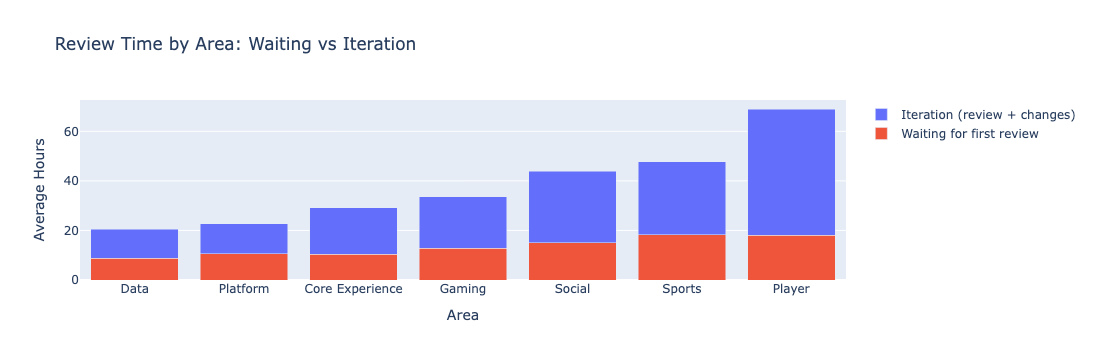


Org average: 38% of review time is waiting for first review


In [29]:
# Visualize review time by area - stacked bar showing waiting vs iteration
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_review_time_by_area['area'],
    y=df_review_time_by_area['avg_first_review_hours'].astype(float),
    name='Waiting for first review',
    marker_color='#EF553B'
))

fig.add_trace(go.Bar(
    x=df_review_time_by_area['area'],
    y=df_review_time_by_area['avg_iteration_hours'].astype(float),
    name='Iteration (review + changes)',
    marker_color='#636EFA'
))

fig.update_layout(
    barmode='stack',
    title='Review Time by Area: Waiting vs Iteration',
    yaxis_title='Average Hours',
    xaxis_title='Area'
)
fig.show()

# Calculate what % is waiting vs iteration
total_review = df_review_time_by_area['avg_review_hours'].astype(float).mean()
total_first = df_review_time_by_area['avg_first_review_hours'].astype(float).mean()
pct_waiting = total_first / total_review * 100
print(f"\nOrg average: {pct_waiting:.0f}% of review time is waiting for first review")

In [30]:
# Review time by PR SIZE
df_review_time_by_size = run_query("""
SELECT 
  CASE 
    WHEN additions + deletions <= 50 THEN '1. XS (≤50)'
    WHEN additions + deletions <= 100 THEN '2. S (51-100)'
    WHEN additions + deletions <= 200 THEN '3. M (101-200)'
    WHEN additions + deletions <= 400 THEN '4. L (201-400)'
    ELSE '5. XL (>400)'
  END as size_bucket,
  COUNT(*) as prs,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as avg_first_review_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND review_time_seconds IS NOT NULL
  AND additions IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1
ORDER BY 1
""")

df_review_time_by_size['avg_iteration_hours'] = (
    df_review_time_by_size['avg_review_hours'].astype(float) - 
    df_review_time_by_size['avg_first_review_hours'].astype(float)
)

print("Review Time by PR Size (Last 12 months)")
print("=" * 60)
df_review_time_by_size

Review Time by PR Size (Last 12 months)


,size_bucket,prs,avg_review_hours,avg_first_review_hours,avg_iteration_hours
0,1. XS (≤50),34450,19.8,11.2,8.6
1,2. S (51-100),6339,39.4,17.7,21.7
2,3. M (101-200),5813,53.1,21.9,31.2
3,4. L (201-400),5024,66.5,20.7,45.8
4,5. XL (>400),9306,91.0,29.8,61.2


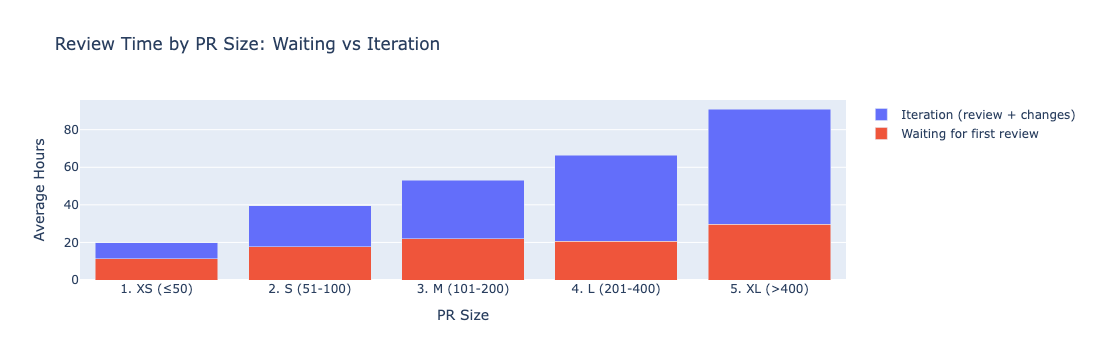


Insight: Large PRs (>400 lines) spend 4.6x longer in review than small PRs (≤50 lines)


In [31]:
# Visualize review time by PR size - stacked bar
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_review_time_by_size['size_bucket'],
    y=df_review_time_by_size['avg_first_review_hours'].astype(float),
    name='Waiting for first review',
    marker_color='#EF553B'
))

fig.add_trace(go.Bar(
    x=df_review_time_by_size['size_bucket'],
    y=df_review_time_by_size['avg_iteration_hours'].astype(float),
    name='Iteration (review + changes)',
    marker_color='#636EFA'
))

fig.update_layout(
    barmode='stack',
    title='Review Time by PR Size: Waiting vs Iteration',
    yaxis_title='Average Hours',
    xaxis_title='PR Size'
)
fig.show()

# Insight
small = df_review_time_by_size[df_review_time_by_size['size_bucket'] == '1. XS (≤50)'].iloc[0]
large = df_review_time_by_size[df_review_time_by_size['size_bucket'] == '5. XL (>400)'].iloc[0]
print(f"\nInsight: Large PRs (>400 lines) spend {float(large['avg_review_hours'])/float(small['avg_review_hours']):.1f}x longer in review than small PRs (≤50 lines)")

In [32]:
# Review time by DAY OF WEEK (when review was requested)
df_review_time_by_day = run_query("""
SELECT 
  DAYOFWEEK(first_review_request_at) as day_num,
  CASE DAYOFWEEK(first_review_request_at)
    WHEN 0 THEN '7. Sunday'
    WHEN 1 THEN '1. Monday'
    WHEN 2 THEN '2. Tuesday'
    WHEN 3 THEN '3. Wednesday'
    WHEN 4 THEN '4. Thursday'
    WHEN 5 THEN '5. Friday'
    WHEN 6 THEN '6. Saturday'
  END as day_name,
  COUNT(*) as prs,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(DATEDIFF('second', first_review_request_at, first_reviewed_at)) / 3600.0, 1) as avg_first_review_hours
FROM RAW_MISC.SWARMIA_PULL_REQUESTS
WHERE pr_status = 'MERGED'
  AND is_excluded = FALSE
  AND review_time_seconds IS NOT NULL
  AND first_review_request_at IS NOT NULL
  AND github_created_at >= DATEADD('month', -12, CURRENT_DATE)
GROUP BY 1, 2
ORDER BY 2
""")

print("Review Time by Day of Week (Last 12 months)")
print("=" * 60)
df_review_time_by_day

Review Time by Day of Week (Last 12 months)


,day_num,day_name,prs,avg_review_hours,avg_first_review_hours
0,1,1. Monday,10377,36.3,13.9
1,2,2. Tuesday,10475,35.2,14.0
2,3,3. Wednesday,10593,35.2,14.4
3,4,4. Thursday,10499,39.0,16.0
4,5,5. Friday,8669,49.5,24.0
5,6,6. Saturday,1097,45.4,164.5
6,0,7. Sunday,439,31.1,31.5


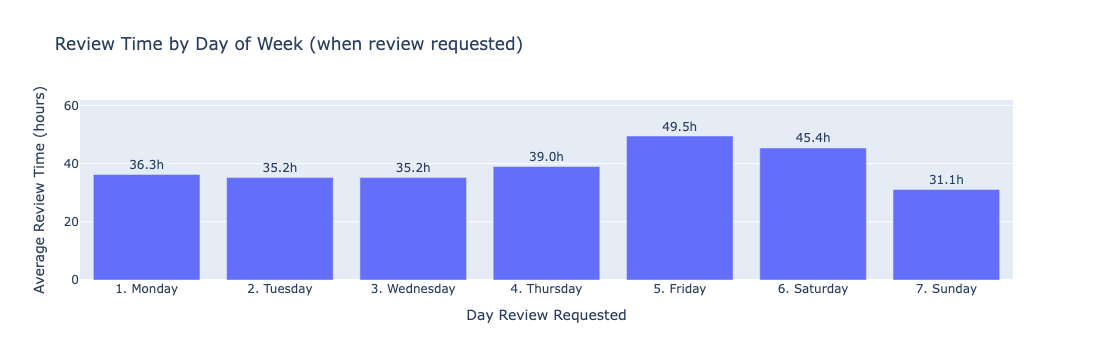


Worst day to request review: 5. Friday (49.5h avg)
Best day to request review: 7. Sunday (31.1h avg)


In [33]:
# Visualize review time by day of week
avg_hours = df_review_time_by_day['avg_review_hours'].astype(float)

fig = px.bar(df_review_time_by_day, x='day_name', y='avg_review_hours',
             title='Review Time by Day of Week (when review requested)',
             text='avg_review_hours')
fig.update_traces(texttemplate='%{text:.1f}h', textposition='outside')
fig.update_layout(
    yaxis_title='Average Review Time (hours)', 
    xaxis_title='Day Review Requested',
    yaxis_range=[0, avg_hours.max() * 1.25]
)
fig.show()

# Find the worst day
worst_day = df_review_time_by_day.loc[df_review_time_by_day['avg_review_hours'].astype(float).idxmax()]
best_day = df_review_time_by_day.loc[df_review_time_by_day['avg_review_hours'].astype(float).idxmin()]
print(f"\nWorst day to request review: {worst_day['day_name']} ({worst_day['avg_review_hours']}h avg)")
print(f"Best day to request review: {best_day['day_name']} ({best_day['avg_review_hours']}h avg)")

In [34]:
# Summary of Review Time deep dive
print("=" * 60)
print("REVIEW TIME - DEEP DIVE SUMMARY")
print("=" * 60)

# Distribution
pct_under_4h = df_review_time_dist[df_review_time_dist['time_bucket'].isin(['1. < 1 hour', '2. 1-4 hours'])]['pct'].astype(float).sum()
pct_over_2_days = df_review_time_dist[df_review_time_dist['time_bucket'].isin(['6. 2-7 days', '7. > 1 week'])]['pct'].astype(float).sum()

print(f"\n1. DISTRIBUTION:")
print(f"   - {pct_under_4h:.0f}% of PRs complete full review within 4 hours")
print(f"   - {pct_over_2_days:.0f}% take more than 2 days in review")

# Waiting vs iteration
total_review = df_review_time_by_area['avg_review_hours'].astype(float).mean()
total_first = df_review_time_by_area['avg_first_review_hours'].astype(float).mean()
pct_waiting = total_first / total_review * 100
print(f"\n2. WAITING VS ITERATION:")
print(f"   - {pct_waiting:.0f}% of review time is waiting for first review")
print(f"   - {100-pct_waiting:.0f}% is actual review/iteration")

# By area
best_area = df_review_time_by_area.iloc[0]
worst_area = df_review_time_by_area.iloc[-1]
print(f"\n3. BY AREA:")
print(f"   - Fastest: {best_area['area']} ({best_area['avg_review_hours']}h avg)")
print(f"   - Slowest: {worst_area['area']} ({worst_area['avg_review_hours']}h avg)")

# By size
small_pr = df_review_time_by_size[df_review_time_by_size['size_bucket'] == '1. XS (≤50)'].iloc[0]
large_pr = df_review_time_by_size[df_review_time_by_size['size_bucket'] == '5. XL (>400)'].iloc[0]
print(f"\n4. BY PR SIZE:")
print(f"   - Small PRs (≤50 lines): {small_pr['avg_review_hours']}h avg")
print(f"   - Large PRs (>400 lines): {large_pr['avg_review_hours']}h avg")
print(f"   - Large PRs take {float(large_pr['avg_review_hours']) / float(small_pr['avg_review_hours']):.1f}x longer")

# By day
print(f"\n5. BY DAY OF WEEK:")
print(f"   - Best: {best_day['day_name']} ({best_day['avg_review_hours']}h)")
print(f"   - Worst: {worst_day['day_name']} ({worst_day['avg_review_hours']}h)")

print("=" * 60)

REVIEW TIME - DEEP DIVE SUMMARY

1. DISTRIBUTION:
   - 66% of PRs complete full review within 4 hours
   - 15% take more than 2 days in review

2. WAITING VS ITERATION:
   - 38% of review time is waiting for first review
   - 62% is actual review/iteration

3. BY AREA:
   - Fastest: Data (17.9h avg)
   - Slowest: Player (62.8h avg)

4. BY PR SIZE:
   - Small PRs (≤50 lines): 19.8h avg
   - Large PRs (>400 lines): 91.0h avg
   - Large PRs take 4.6x longer

5. BY DAY OF WEEK:
   - Best: 7. Sunday (31.1h)
   - Worst: 5. Friday (49.5h)


## 6. Breakdown by Area

Do different areas have different bottlenecks?

In [35]:
# Areas to analyze (same as throughput analysis)
AREAS = ['Core Experience', 'Data', 'Gaming', 'Platform', 'Player', 'Social', 'Sports']

print(f"Analyzing {len(AREAS)} areas: {', '.join(AREAS)}")

Analyzing 7 areas: Core Experience, Data, Gaming, Platform, Player, Social, Sports


In [36]:
# Cycle time by area (last 12 months)
areas_str = "', '".join(AREAS)

df_area_cycle = run_query(f"""
WITH pr_flattened AS (
  SELECT
    f.value::string as area,
    pr.cycle_time_seconds,
    pr.progress_time_seconds,
    pr.review_time_seconds,
    pr.merge_time_seconds,
    pr.additions + pr.deletions as lines_changed
  FROM RAW_MISC.SWARMIA_PULL_REQUESTS pr,
  LATERAL FLATTEN(input => pr.owner_team_names) f
  WHERE pr.pr_status = 'MERGED'
    AND pr.is_excluded = FALSE
    AND pr.cycle_time_seconds IS NOT NULL
    AND f.value::string IN ('{areas_str}')
    AND pr.github_created_at >= DATEADD('month', -12, CURRENT_DATE)
)
SELECT
  area,
  COUNT(*) as prs,
  ROUND(AVG(cycle_time_seconds) / 86400.0, 1) as avg_cycle_days,
  ROUND(AVG(progress_time_seconds) / 3600.0, 1) as avg_progress_hours,
  ROUND(AVG(review_time_seconds) / 3600.0, 1) as avg_review_hours,
  ROUND(AVG(merge_time_seconds) / 3600.0, 1) as avg_merge_hours,
  ROUND(AVG(lines_changed), 0) as avg_lines
FROM pr_flattened
GROUP BY 1
ORDER BY avg_cycle_days
""")

print("Cycle Time by Area (Last 12 months)")
df_area_cycle

Cycle Time by Area (Last 12 months)


,area,prs,avg_cycle_days,avg_progress_hours,avg_review_hours,avg_merge_hours,avg_lines
0,Data,10669,1.4,18.0,17.9,5.5,847
1,Platform,7457,1.5,16.2,18.3,7.2,795
2,Core Experience,3791,2.4,30.9,26.2,6.2,1148
3,Sports,17139,3.4,29.8,45.8,16.9,424
4,Gaming,5995,3.6,46.3,32.2,12.4,535
5,Social,2717,4.1,38.6,43.1,20.7,412
6,Player,12553,5.2,45.1,62.8,28.8,488


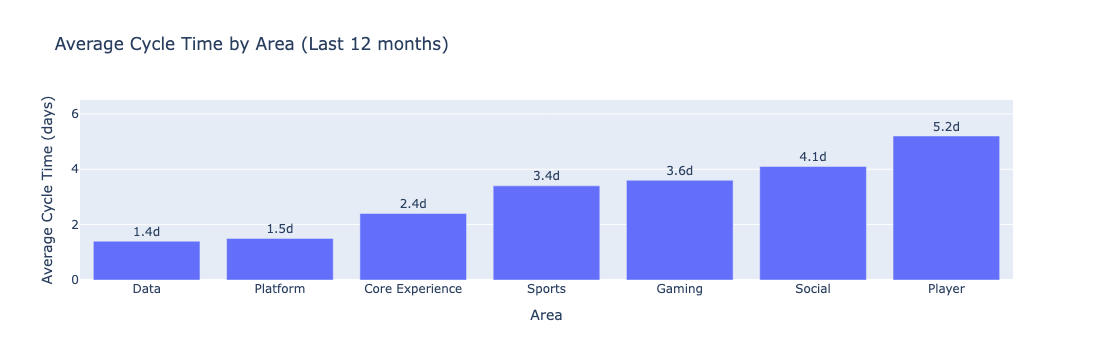

In [37]:
# Bar chart: Cycle time by area
max_val = df_area_cycle['avg_cycle_days'].astype(float).max()

fig = px.bar(df_area_cycle, x='area', y='avg_cycle_days',
             title='Average Cycle Time by Area (Last 12 months)',
             text='avg_cycle_days')
fig.update_traces(texttemplate='%{text:.1f}d', textposition='outside')
fig.update_layout(
    yaxis_title='Average Cycle Time (days)', 
    xaxis_title='Area',
    yaxis_range=[0, max_val * 1.25]
)
fig.show()

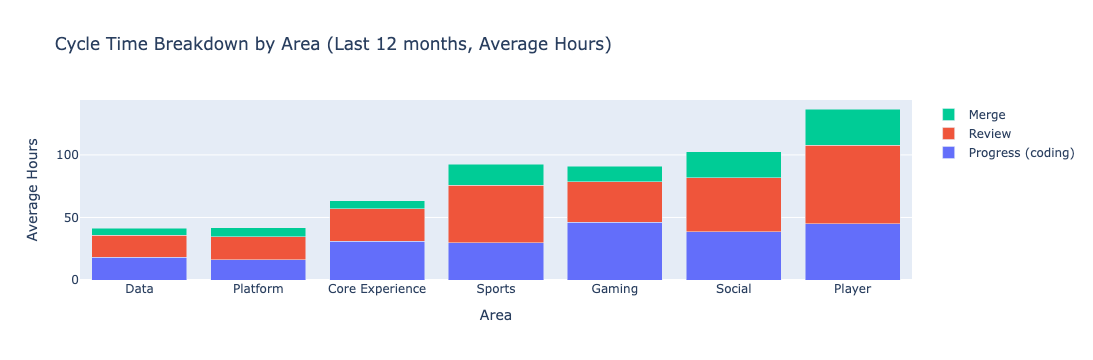

In [38]:
# Stacked bar: Where does time go by area? (AVERAGE hours)
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_area_cycle['area'],
    y=df_area_cycle['avg_progress_hours'],
    name='Progress (coding)'
))
fig.add_trace(go.Bar(
    x=df_area_cycle['area'],
    y=df_area_cycle['avg_review_hours'],
    name='Review'
))
fig.add_trace(go.Bar(
    x=df_area_cycle['area'],
    y=df_area_cycle['avg_merge_hours'],
    name='Merge'
))

fig.update_layout(
    barmode='stack',
    title='Cycle Time Breakdown by Area (Last 12 months, Average Hours)',
    yaxis_title='Average Hours',
    xaxis_title='Area'
)
fig.show()

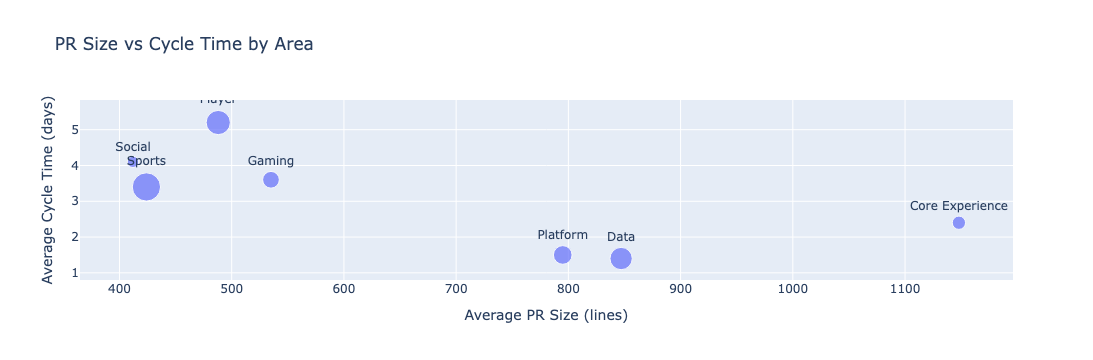


Insight: Areas with larger PRs tend to have longer cycle times


In [39]:
# PR size vs cycle time by area
fig = px.scatter(df_area_cycle, x='avg_lines', y='avg_cycle_days',
                 text='area', size='prs',
                 title='PR Size vs Cycle Time by Area')
fig.update_traces(textposition='top center')
fig.update_layout(
    xaxis_title='Average PR Size (lines)',
    yaxis_title='Average Cycle Time (days)'
)
fig.show()

print("\nInsight: Areas with larger PRs tend to have longer cycle times")

## 7. Summary & Key Findings

In [40]:
# Calculate key metrics for the report
print("=" * 60)
print("KEY METRICS FOR REPORT (12-month baseline)")
print("=" * 60)

# Cycle time
recent_cycle = df_cycle[df_cycle['month_dt'] >= df_cycle['month_dt'].max() - pd.DateOffset(months=12)]
print(f"\nCycle Time:")
print(f"  Average: {recent_cycle['avg_cycle_days'].mean():.1f} days")
print(f"  Median: {recent_cycle['median_cycle_days'].mean():.1f} days")

# Breakdown
recent_breakdown = df_breakdown[df_breakdown['month_dt'] >= df_breakdown['month_dt'].max() - pd.DateOffset(months=12)]
progress = recent_breakdown['avg_progress_hours'].mean()
review = recent_breakdown['avg_review_hours'].mean()
merge = recent_breakdown['avg_merge_hours'].mean()
total = progress + review + merge
print(f"\nBreakdown (average hours):")
print(f"  Progress: {progress:.1f}h ({progress/total*100:.0f}%)")
print(f"  Review: {review:.1f}h ({review/total*100:.0f}%)")
print(f"  Merge: {merge:.1f}h ({merge/total*100:.0f}%)")

# PR Size
recent_size = df_size[df_size['month_dt'] >= df_size['month_dt'].max() - pd.DateOffset(months=12)]
print(f"\nPR Size:")
print(f"  Average: {recent_size['avg_lines'].mean():.0f} lines")
print(f"  Median: {recent_size['median_lines'].mean():.0f} lines")
print(f"  % Large (>400): {recent_size['pct_large'].mean():.1f}%")

# Time to first review
recent_review = df_first_review[df_first_review['month_dt'] >= df_first_review['month_dt'].max() - pd.DateOffset(months=12)]
print(f"\nTime to First Review:")
print(f"  Average: {recent_review['avg_hours_to_first_review'].mean():.1f} hours")
print(f"  Median: {recent_review['median_hours_to_first_review'].mean():.1f} hours")

print("=" * 60)

KEY METRICS FOR REPORT (12-month baseline)

Cycle Time:
  Average: 2.9 days
  Median: 0.0 days

Breakdown (average hours):
  Progress: 31.5h (37%)
  Review: 40.0h (47%)
  Merge: 14.2h (17%)

PR Size:
  Average: 1103 lines
  Median: 16 lines
  % Large (>400): 11.6%

Time to First Review:
  Average: 18.9 hours
  Median: 0.3 hours


## Next Steps

1. Update the report markdown with actual numbers and insights
2. Create review checklist for independent verification